In [ ]:
!pip install kagglehub

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import matplotlib.pyplot as plt

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import kagglehub

path = kagglehub.dataset_download("subhajournal/busi-breast-ultrasound-images-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'busi-breast-ultrasound-images-dataset' dataset.
Dataset path: /kaggle/input/busi-breast-ultrasound-images-dataset


label
1    437
2    210
0    133
Name: count, dtype: int64


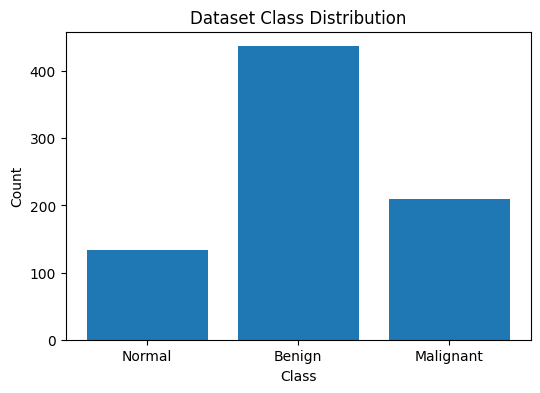

In [ ]:
image_paths = []
labels = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".png") and "mask" not in file:
            if "benign" in root.lower():
                label = "benign"
            elif "malignant" in root.lower():
                label = "malignant"
            elif "normal" in root.lower():
                label = "normal"
            else:
                continue

            image_paths.append(os.path.join(root, file))
            labels.append(label)

df = pd.DataFrame({"image": image_paths, "label": labels})

label_map = {"normal": 0, "benign": 1, "malignant": 2}
df["label"] = df["label"].map(label_map)

print(df["label"].value_counts())

import matplotlib.pyplot as plt

class_names = ["Normal", "Benign", "Malignant"]
counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(class_names, counts)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df["label"], random_state=42)

print(len(train_df), len(val_df), len(test_df))

563 100 117


**DATASET CLASS**

In [ ]:
class BUSIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]["image"]).convert("RGB")
        label = self.df.iloc[idx]["label"]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label)

**TRANSFORMS**

In [ ]:
basic_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

aug_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

**DATALOADERS**

In [ ]:
train_dataset = BUSIDataset(train_df, basic_transform)
val_dataset = BUSIDataset(val_df, basic_transform)
test_dataset = BUSIDataset(test_df, basic_transform)

train_aug_dataset = BUSIDataset(train_df, aug_transform)

# Weighted Sampling
class_counts = train_df["label"].value_counts().sort_index()
weights = 1.0 / class_counts
sample_weights = train_df["label"].map(weights).values

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
train_loader_aug = DataLoader(train_aug_dataset, batch_size=32, shuffle=True)
train_loader_weighted = DataLoader(train_dataset, batch_size=32, sampler=sampler)

val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

**MODEL**

In [ ]:
class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.depthwise = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1)

        self.bn1 = nn.BatchNorm2d(in_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.depthwise(x)))
        x = self.relu(self.bn2(self.pointwise(x)))
        return x


class DSCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,2,1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            DepthwiseSeparableBlock(32,64),
            DepthwiseSeparableBlock(64,128,2),
            DepthwiseSeparableBlock(128,128),

            DepthwiseSeparableBlock(128,256,2),
            DepthwiseSeparableBlock(256,256),

            DepthwiseSeparableBlock(256,512,2),

            *[DepthwiseSeparableBlock(512,512) for _ in range(3)],

            DepthwiseSeparableBlock(512,1024,2),
            DepthwiseSeparableBlock(1024,1024),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(1024,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,3)
        )

    def forward(self,x):
        return self.classifier(self.features(x))

**FOCAL LOSS**

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

**MODEL TRAINING**

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15):
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = FocalLoss()

    best_acc = 0

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()

            pred = out.argmax(1)
            total += y.size(0)
            correct += (pred==y).sum().item()

        train_acc = correct/total

        # Validation
        model.eval()
        val_correct, val_total = 0,0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                pred = out.argmax(1)

                val_total += y.size(0)
                val_correct += (pred==y).sum().item()

        val_acc = val_correct/val_total

        print(f"Epoch {epoch+1}: Train={train_acc:.3f} Val={val_acc:.3f}")

    return model

In [ ]:
model = DSCNN()

train_loader_aug_weighted = DataLoader(
    train_aug_dataset,
    batch_size=32,
    sampler=sampler
)

model = train_model(
    model,
    train_loader_aug_weighted,
    val_loader,
    epochs=20
)

Epoch 1: Train=0.426 Val=0.270
Epoch 2: Train=0.501 Val=0.270
Epoch 3: Train=0.547 Val=0.310
Epoch 4: Train=0.591 Val=0.500
Epoch 5: Train=0.613 Val=0.570
Epoch 6: Train=0.675 Val=0.510
Epoch 7: Train=0.705 Val=0.520
Epoch 8: Train=0.739 Val=0.610
Epoch 9: Train=0.718 Val=0.660
Epoch 10: Train=0.705 Val=0.710
Epoch 11: Train=0.755 Val=0.760
Epoch 12: Train=0.783 Val=0.670
Epoch 13: Train=0.776 Val=0.750
Epoch 14: Train=0.783 Val=0.690
Epoch 15: Train=0.817 Val=0.620
Epoch 16: Train=0.808 Val=0.760
Epoch 17: Train=0.835 Val=0.780
Epoch 18: Train=0.821 Val=0.710
Epoch 19: Train=0.783 Val=0.670
Epoch 20: Train=0.829 Val=0.580


**EVALUATION**

              precision    recall  f1-score   support

           0       0.38      0.70      0.49        20
           1       0.84      0.58      0.68        66
           2       0.63      0.71      0.67        31

    accuracy                           0.63       117
   macro avg       0.62      0.66      0.61       117
weighted avg       0.71      0.63      0.65       117

Accuracy: 0.6324786324786325
F1: 0.6468411731569625
Confusion Matrix:
 [[14  2  4]
 [19 38  9]
 [ 4  5 22]]

Prediction Distribution:
1    45
0    37
2    35
Name: count, dtype: int64


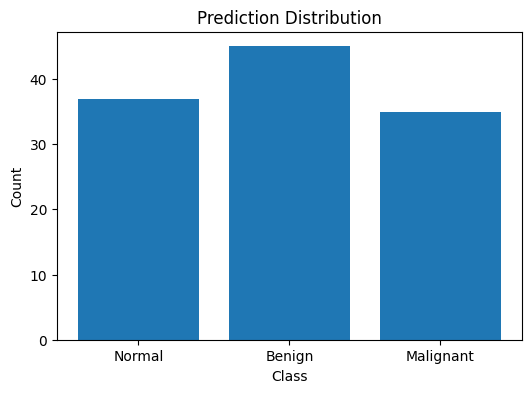

In [ ]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            out = model(x)
            pred = out.argmax(1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(pred)

    print(classification_report(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true,y_pred))
    print("F1:", f1_score(y_true,y_pred,average="weighted"))

    print("Confusion Matrix:\n", confusion_matrix(y_true,y_pred))

    print("\nPrediction Distribution:")
    print(pd.Series(y_pred).value_counts())

    pred_counts = pd.Series(y_pred).value_counts().sort_index()

    plt.figure(figsize=(6,4))
    plt.bar(class_names, pred_counts)
    plt.title("Prediction Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

evaluate(model, test_loader)